# 02 · Model Development
### Fraud Risk Intelligence Platform

This is the "show your work" behind `src/train.py`: a five-model bake-off, scored on a **time-based** train/test split against the SQL rule baseline.

The line-up is deliberate – a linear baseline, a bagging ensemble, two gradient boosters (the real-world fraud workhorses), and one *unsupervised* contrast:

1. **Logistic Regression** – linear baseline
2. **Random Forest** – bagging ensemble
3. **XGBoost** – gradient boosting
4. **LightGBM** – gradient boosting (common in production fraud stacks)
5. **Isolation Forest** – unsupervised anomaly detection (never sees the label)

**Prereqts:** PostgreSQL running, `.env` set, venv active, and `lightgbm` installed (`pip install lightgbm`). Training the five models on ~1.1M rows takes a few minutes – Random Forest and Isolation Forest are the slow ones.

In [1]:
import sys
from pathlib import Path

for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "db.py").exists():
        sys.path.insert(0, str(_p / "src"))
        PROJECT_ROOT = _p
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

NAVY, ORANGE, FRAUD, LEGIT, MUTED = "#22344A", "#E8853A", "#D64545", "#1F9D63", "#7C8A99"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#D7DEE6",
    "axes.grid": True, "grid.color": "#EAEFF4", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": NAVY,
    "figure.dpi": 110,
})

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from features import load_feature_matrix, time_split, FEATURES

## The split

Fraud is a time-series problem: in production you score *future* transactions from *past* ones. A random split would leak future information backward and inflate the scores, so `time_split` trains on everything before 2020-04-01 and tests on Apr–Jun 2020. The imbalance should hold (~0.58%) in both halves.

In [2]:
train, test = time_split(load_feature_matrix())
Xtr, ytr = train[FEATURES], train["is_fraud"]
Xte, yte = test[FEATURES],  test["is_fraud"]
print(f"train: {len(Xtr):,} rows  ({100*ytr.mean():.3f}% fraud)")
print(f"test:  {len(Xte):,} rows  ({100*yte.mean():.3f}% fraud)")
print("features:", FEATURES)

train: 1,097,693 rows  (0.578% fraud)
test:  198,982 rows  (0.584% fraud)
features: ['amt', 'amt_zscore', 'txn_count_24h', 'txn_count_7d', 'amt_sum_24h', 'cardholder_age', 'txn_hour', 'is_weekend', 'is_night', 'home_merchant_km']


## The bar to beat

The SQL rule engine (`sql/04_rules.sql`) catches **43.9% of fraud at 17.0% precision** – cheap, explainable coverage, but a brutal false-positive load (≈5 false alarms per real fraud). Every model below is measured at that same 43.9% recall so the precision numbers are directly comparable.

In [3]:
RULE_RECALL, RULE_PRECISION = 0.439, 0.17

def prec_at_recall(y, s, target=RULE_RECALL):
    p, r, _ = precision_recall_curve(y, s)
    return p[np.argmin(np.abs(r - target))]

spw = (ytr == 0).sum() / (ytr == 1).sum()   # scale_pos_weight for the boosters
models, scores, results = {}, {}, {}

def run(name, model, unsup=False):
    if unsup:
        model.fit(Xtr)
        s = -model.score_samples(Xte)          # higher = more anomalous
    else:
        model.fit(Xtr, ytr)
        s = model.predict_proba(Xte)[:, 1]
    models[name], scores[name] = model, s
    results[name] = {"PR-AUC": average_precision_score(yte, s),
                     "ROC-AUC": roc_auc_score(yte, s),
                     "P@44%recall": prec_at_recall(yte, s)}
    print(f"{name:24s} PR-AUC={results[name]['PR-AUC']:.3f}  "
          f"P@44%recall={results[name]['P@44%recall']*100:.1f}%")
    return model

In [4]:
run("Logistic Regression",
    make_pipeline(StandardScaler(),
                  LogisticRegression(class_weight="balanced", max_iter=1000)))

run("Random Forest",
    RandomForestClassifier(n_estimators=200, max_depth=12, class_weight="balanced",
                           n_jobs=-1, random_state=42))

run("XGBoost",
    XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, scale_pos_weight=spw,
                  eval_metric="aucpr", tree_method="hist", n_jobs=-1))

run("LightGBM",
    LGBMClassifier(n_estimators=400, learning_rate=0.05, scale_pos_weight=spw,
                   n_jobs=-1, verbose=-1))

run("Isolation Forest",
    IsolationForest(n_estimators=200, contamination=float(ytr.mean()),
                    random_state=42, n_jobs=-1), unsup=True)

Logistic Regression      PR-AUC=0.402  P@44%recall=53.5%
Random Forest            PR-AUC=0.846  P@44%recall=98.3%
XGBoost                  PR-AUC=0.883  P@44%recall=99.2%
LightGBM                 PR-AUC=0.870  P@44%recall=98.5%
Isolation Forest         PR-AUC=0.326  P@44%recall=45.8%


IsolationForest(contamination=0.005778482690515472, n_estimators=200, n_jobs=-1,
                random_state=42)

## Results

`PR-AUC` is the metric to trust on imbalanced data – random guessing scores ≈ the fraud rate (0.006), so anything in the 0.4–0.9 range is real structure. ROC-AUC looks flatteringly high here and is reported only for completeness.

In [5]:
res = pd.DataFrame(results).T.sort_values("PR-AUC", ascending=False)
out = res.copy()
out["PR-AUC"] = out["PR-AUC"].round(3)
out["ROC-AUC"] = out["ROC-AUC"].round(3)
out["P@44%recall"] = (out["P@44%recall"] * 100).round(1).astype(str) + "%"
out

,PR-AUC,ROC-AUC,P@44%recall
XGBoost,0.883,0.996,99.2%
LightGBM,0.870,0.995,98.5%
Random Forest,0.846,0.995,98.3%
Logistic Regression,0.402,0.977,53.5%
Isolation Forest,0.326,0.961,45.8%


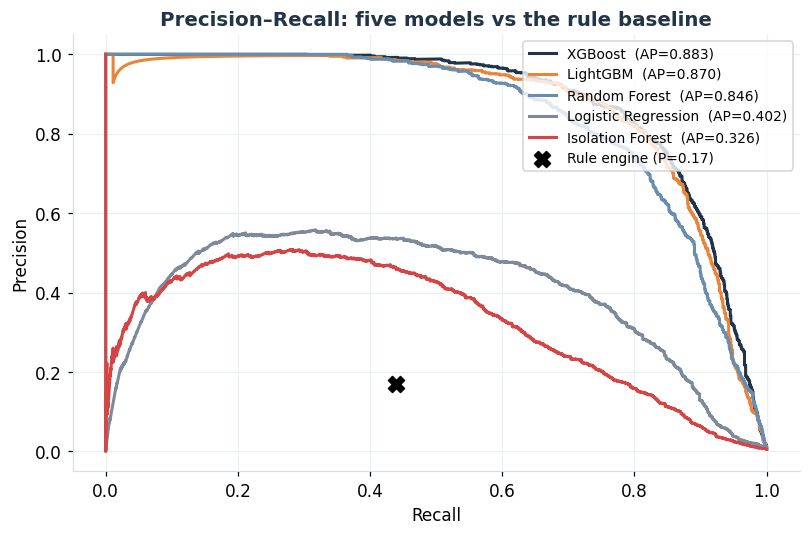

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
palette = {"XGBoost": NAVY, "LightGBM": ORANGE, "Random Forest": "#6A8CAF",
           "Logistic Regression": MUTED, "Isolation Forest": FRAUD}
for name in res.index:
    p, r, _ = precision_recall_curve(yte, scores[name])
    ax.plot(r, p, color=palette.get(name, NAVY), lw=2,
            label=f"{name}  (AP={results[name]['PR-AUC']:.3f})")
ax.scatter([RULE_RECALL], [RULE_PRECISION], color="black", marker="X", s=110, zorder=5,
           label="Rule engine (P=0.17)")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision–Recall: five models vs the rule baseline")
ax.legend(fontsize=9, loc="upper right"); plt.tight_layout(); plt.show()

**Read:** the two gradient boosters lead (XGBoost ≈ 0.88, LightGBM ≈ 0.87), Random Forest close behind (≈ 0.85), Logistic Regression well back (≈ 0.40 – a linear model only gets you partway, so the non-linear interactions matter), and **Isolation Forest at the bottom (≈ 0.33)**. That last result is the teaching point, not a bug: unsupervised anomaly detection underperforms supervised methods when you *have* labels. It earns its place by showing you know when each approach applies.

## Why XGBoost – feature importance & error profile

XGBoost is kept as the production model (wired through `src/risk.py` and the dashboard). Two diagnostics:

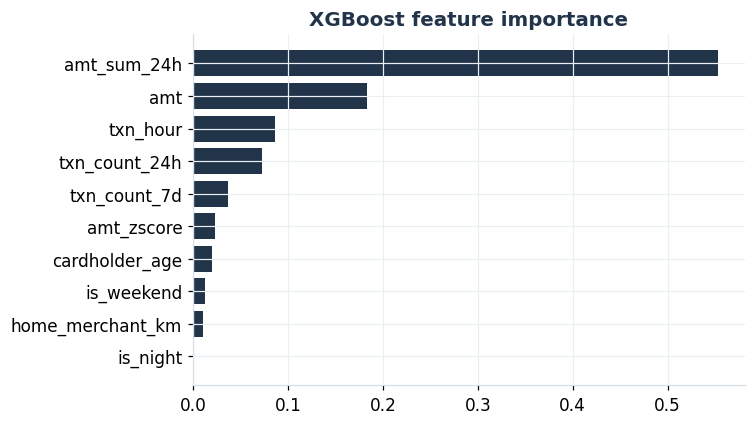

amt_sum_24h         0.553
amt                 0.184
txn_hour            0.087
txn_count_24h       0.073
txn_count_7d        0.037
amt_zscore          0.023
cardholder_age      0.020
is_weekend          0.013
home_merchant_km    0.010
is_night            0.000
dtype: float32

In [7]:
imp = pd.Series(models["XGBoost"].feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values, color=NAVY)
ax.set_title("XGBoost feature importance")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(3)

**Closed loop to the EDA:** the amount family (`amt_sum_24h`, `amt`) tops the importances – exactly the signal that stood out in notebook 01. It surfaces through `amt_sum_24h` rather than `amt_zscore` because trees prefer splitting on raw, granular amounts over a pre-standardized score. Note too that `amt_zscore` (the one feature with mild lookahead) sits near the bottom, so the result is robust to that leakage caveat.

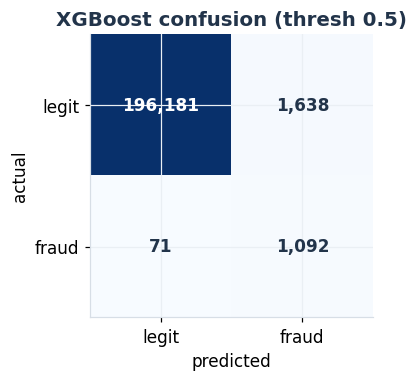

[[196181   1638]
 [    71   1092]]


In [8]:
pred = (scores["XGBoost"] >= 0.5).astype(int)
cm = confusion_matrix(yte, pred)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["legit", "fraud"]); ax.set_yticks([0, 1], ["legit", "fraud"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title("XGBoost confusion (thresh 0.5)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else NAVY, fontweight="bold")
plt.tight_layout(); plt.show()
print(cm)

## The caveat that makes this credible

Numbers this clean (≈99% precision at the rules' recall) are partly a property of **Sparkov being synthetic** – its fraud is generated with a strong amount-based pattern, which makes it unusually separable. Real-world fraud is far messier and no production system hits these figures. State it plainly in the write-up:

> *On this synthetic dataset the model lifts precision from 17% to ~99% at equal recall; these figures > are optimistic relative to production fraud, where the signal is weaker.*

That sentence shows you know the difference between a benchmark and a deployment.

---

### Next
`src/risk.py` turns these probabilities into the **expected-loss alert ranking** (`P(fraud) × amount`) that powers the dashboard – the step that converts a classifier into a capacity-aware review queue. The production model is persisted by `train.py` as `models/xgb_fraud.pkl`; this notebook intentionally doesn't overwrite it.